# Reproduce SMITH Figure 3c-f

This notebook regenerates manuscript-matched data panels from real H5AD inputs; it does not read the packaged reference-output tables. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/regulatory_section/02_SMITH_Regulatory_Activity_source.ipynb).

## Configure real inputs and fresh outputs

In [1]:
from pathlib import Path
import hashlib, json, os, subprocess, sys
import pandas as pd
from IPython.display import Image, display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'regulatory'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", 1))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


## Verify input files

In [2]:
inputs = ['regulatory_activity/elegans/splits/elegans_tf/split_1/train.h5ad', 'regulatory_activity/elegans/splits/elegans_tf/split_1/test.h5ad', 'regulatory_activity/elegans/splits/elegans_mirna/split_1/train.h5ad', 'regulatory_activity/elegans/splits/elegans_mirna/split_1/test.h5ad']
rows = []
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    rows.append({"file": relative, "bytes": path.stat().st_size, "sha256": sha256_file(path)})
display(pd.DataFrame(rows))


,file,bytes,sha256
0,regulatory_activity/elegans/splits/elegans_tf/...,171431555,6b7bfa064ed119bf6e1891c88550894db94d454c99837d...
1,regulatory_activity/elegans/splits/elegans_tf/...,115530989,31ee972b9b5ad2131bd2f8cb80f5a0cae02b14e26dc284...
2,regulatory_activity/elegans/splits/elegans_mir...,39587756,9240ad2e17a70cdb4de50351d1be03284d98e8dc4cca89...
3,regulatory_activity/elegans/splits/elegans_mir...,27111860,0d3b1311e8b4b86d4eb39bbcc1b9902e6675100ec4a8b5...


## Run the workflow for Figure 3c-f

In [3]:
command = [sys.executable, str(ROOT / 'reproducibility/workflows/regulatory_activity/run_tutorial.py'), "--data-root", str(DATA_ROOT), "--output-dir", str(CASE_OUTPUT), "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--datasets', 'elegans_tf,elegans_mirna', '--splits', 'split_1', '--methods', 'SMITH', '--seeds', '1', '--max-cells', '3000'] + ["--force"]
display_command = ["python", 'reproducibility/workflows/regulatory_activity/run_tutorial.py', "--data-root", "data/tutorials", "--output-dir", "outputs/tutorials/regulatory", "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--datasets', 'elegans_tf,elegans_mirna', '--splits', 'split_1', '--methods', 'SMITH', '--seeds', '1', '--max-cells', '3000'] + ["--force"]
print(" ".join(display_command))
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
print("Generated", manifest["manuscript_figure"], "data from fresh workflow outputs.")


python reproducibility/workflows/regulatory_activity/run_tutorial.py --data-root data/tutorials --output-dir outputs/tutorials/regulatory --device cpu --epochs 1 --datasets elegans_tf,elegans_mirna --splits split_1 --methods SMITH --seeds 1 --max-cells 3000 --force


Generated Figure 3c-f data from fresh workflow outputs.


## Inspect newly generated figure data

In [4]:
for relative in ['figure_data/figure3_c_f_summary.tsv']:
    path = CASE_OUTPUT / relative
    print(relative)
    display(pd.read_csv(path, sep="\t").head(20))


figure_data/figure3_c_f_summary.tsv


,dataset,panel_size,method,n,cell_type_accuracy_mean,cell_type_accuracy_std,developmental_time_pearson_mean,developmental_time_pearson_std
0,elegans_mirna,16,SMITH,1,0.392399,NaN,0.911278,NaN
1,elegans_mirna,24,SMITH,1,0.403465,NaN,0.964788,NaN
2,elegans_mirna,32,SMITH,1,0.416427,NaN,0.965143,NaN
3,elegans_tf,32,SMITH,1,0.507588,NaN,0.821501,NaN
4,elegans_tf,64,SMITH,1,0.537267,NaN,0.846343,NaN
5,elegans_tf,128,SMITH,1,0.549487,NaN,0.862197,NaN


## Draw panels from this run

The quick hosted run below has the manuscript axes and panel definitions, but only the methods/repeats actually executed above. Use the full command to regenerate the complete multi-method manuscript comparison.

{
  "png": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/regulatory/figures/figure3_c_f_reproduced.png",
  "pdf": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/regulatory/figures/figure3_c_f_reproduced.pdf",
  "svg": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/regulatory/figures/figure3_c_f_reproduced.svg"
}


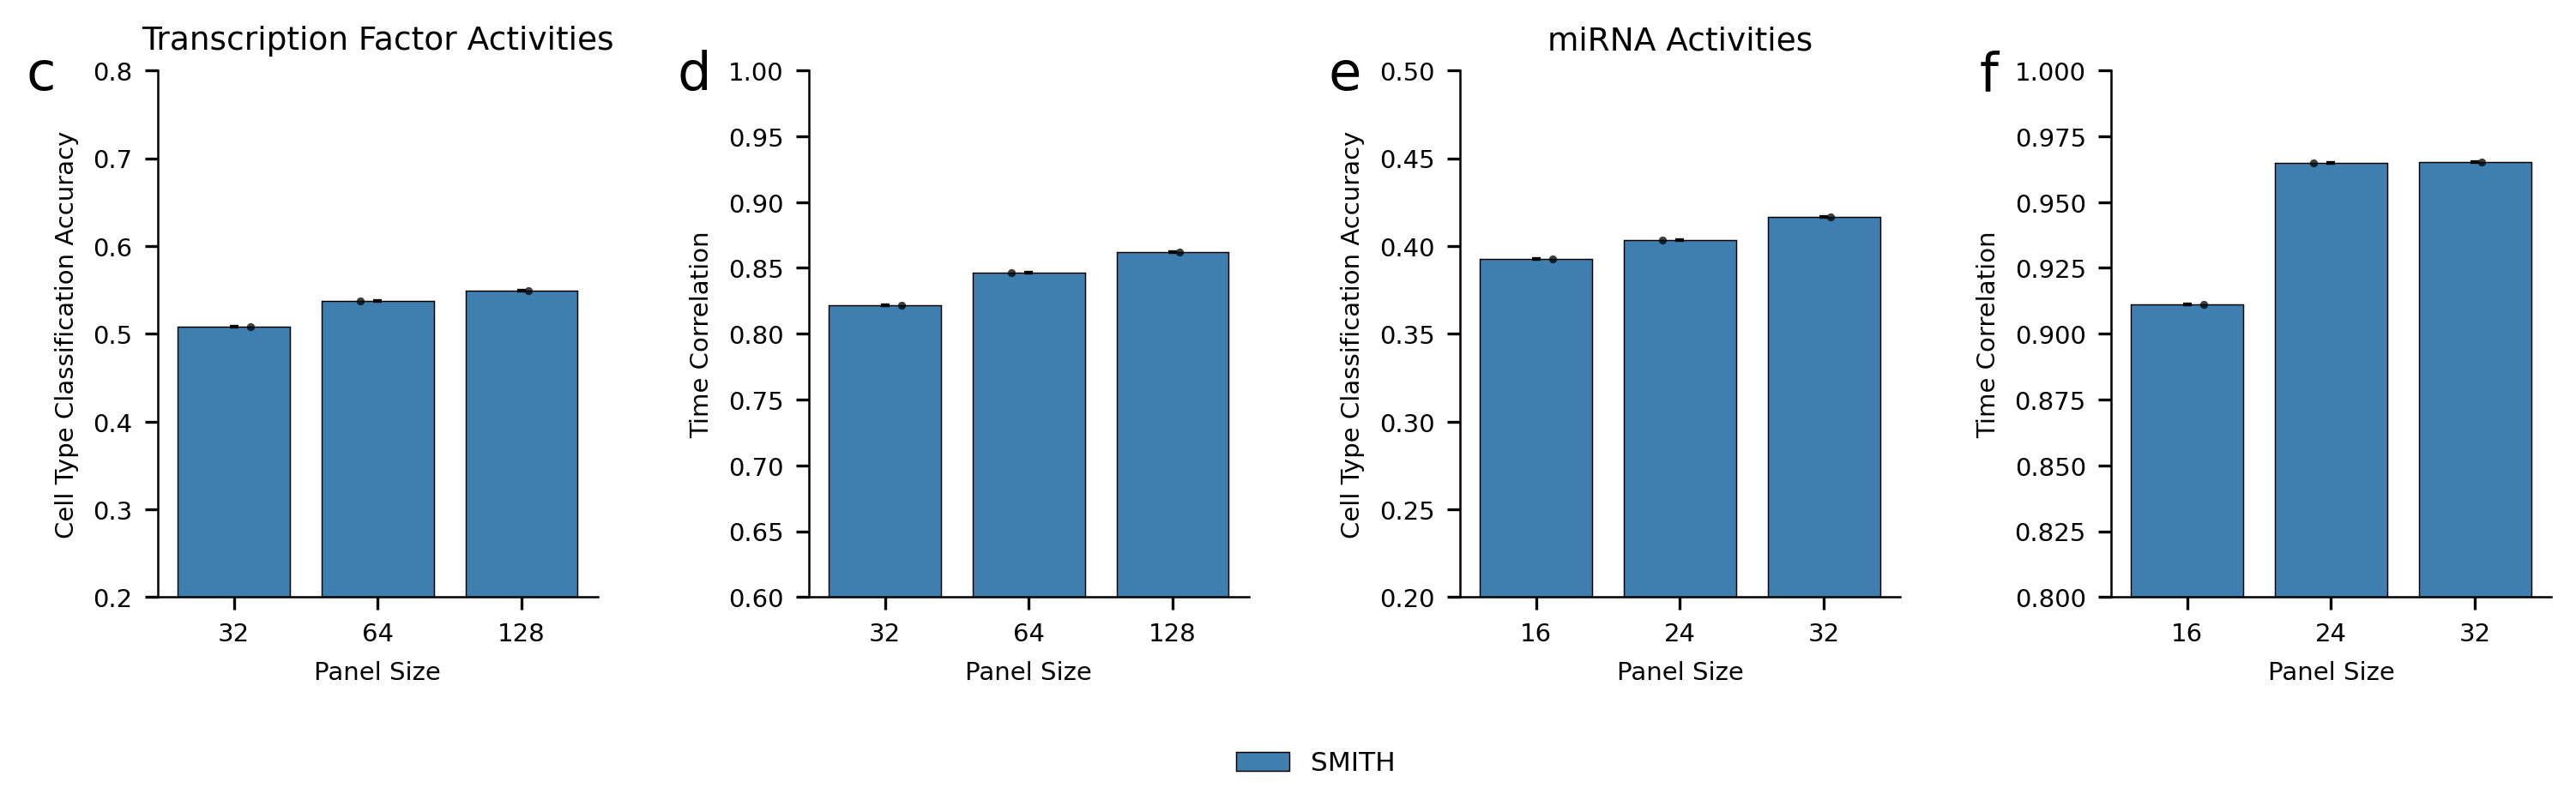

Editable exports: /workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/regulatory/figures/figure3_c_f_reproduced.pdf /workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/regulatory/figures/figure3_c_f_reproduced.svg


In [5]:
figure_prefix = CASE_OUTPUT / 'figures/figure3_c_f_reproduced'
plot_command = [sys.executable, str(ROOT / 'reproducibility/workflows/regulatory_activity/plot_figure3.py'), '--values', str(CASE_OUTPUT / 'figure_data/figure3_c_f_values.tsv'), "--output-prefix", str(figure_prefix)]
subprocess.run(plot_command, cwd=ROOT, check=True)
display(Image(filename=str(figure_prefix.with_suffix(".png"))))
print("Editable exports:", figure_prefix.with_suffix(".pdf"), figure_prefix.with_suffix(".svg"))


## Full manuscript command

Append the following paper-scale arguments to the workflow command:

```text
--splits split_1,split_2,split_3,split_4,split_5 --methods SMITH,PERSIST-class,PERSIST,ActiveSVM,scGIST,scGeneFit,Spapros --baseline-root external/SMITH_baselines/GPS_tools-main/baselines --baseline-python PERSIST=/opt/envs/persist/bin/python --baseline-python PERSIST-class=/opt/envs/persist/bin/python --baseline-python scGIST=/opt/envs/scgist/bin/python --epochs 200
```

This executed page uses one real TF split, one real miRNA split and SMITH only to keep the hosted example tractable. The paper command above regenerates Figure 3c-f with all five lineage-aware splits and manuscript baselines. Figure 3h-k additionally require versioned module, TF-pair and scRNA-to-TF transfer inputs and are not represented by substitute plots.